### Reconstruindo modelo cinematico com $\hat{\theta}$

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

Datasets = []
PREDICTORS = ["PwmD", "PwmE"]   
PHYSICAL_PREDICTORS = ["Wd", "We"]   
TARGET = ["Theta", "X", "Y"]       
TIME_STEPS = 3
TITLES = ["Train_1", "Train_2", "Test_1", "Test_2", "Test_3", "Val", "LSG_1", "LSG_2"]

for title in TITLES:
    df = pd.read_excel("./Data/Datasets.xlsx", sheet_name=title)
    df_theta = pd.read_excel("./Data/Theta.xlsx", sheet_name=title)

    df["Theta_ens"] = df_theta["Theta_ens"]
    
    df = df.dropna().reset_index(drop=True)

    Datasets.append(df)

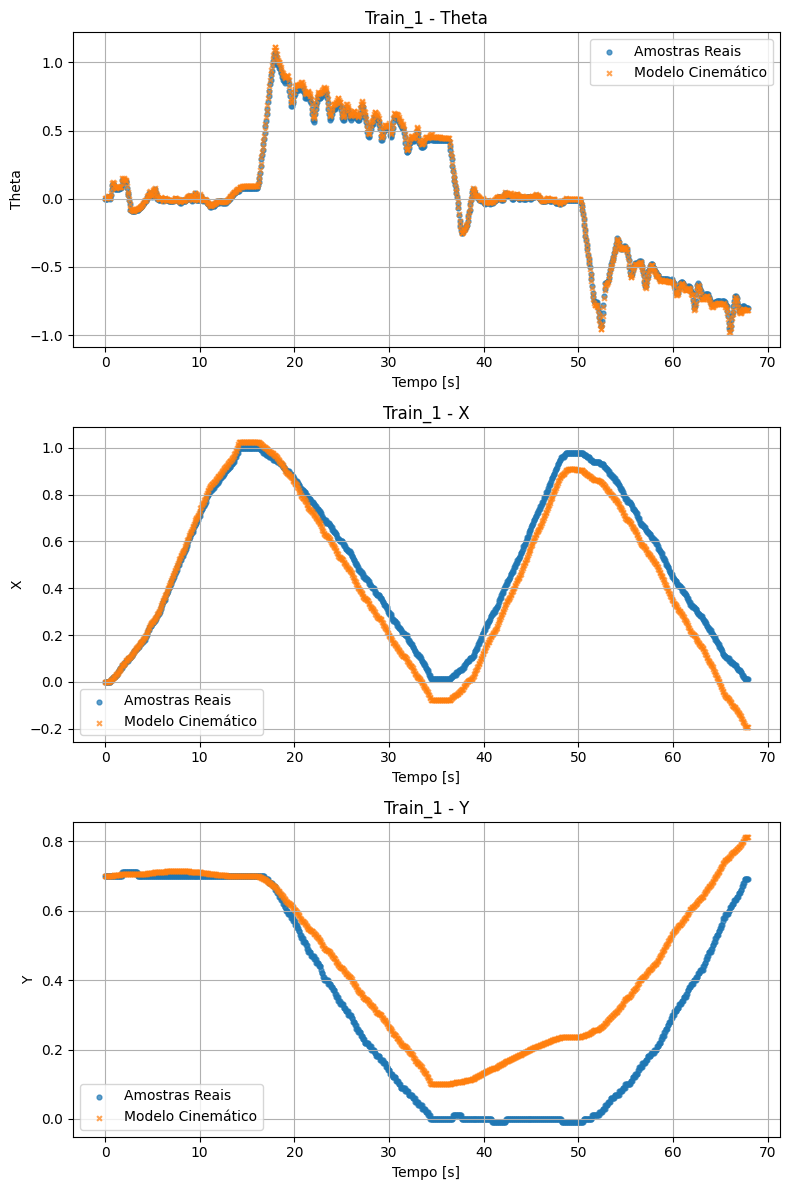

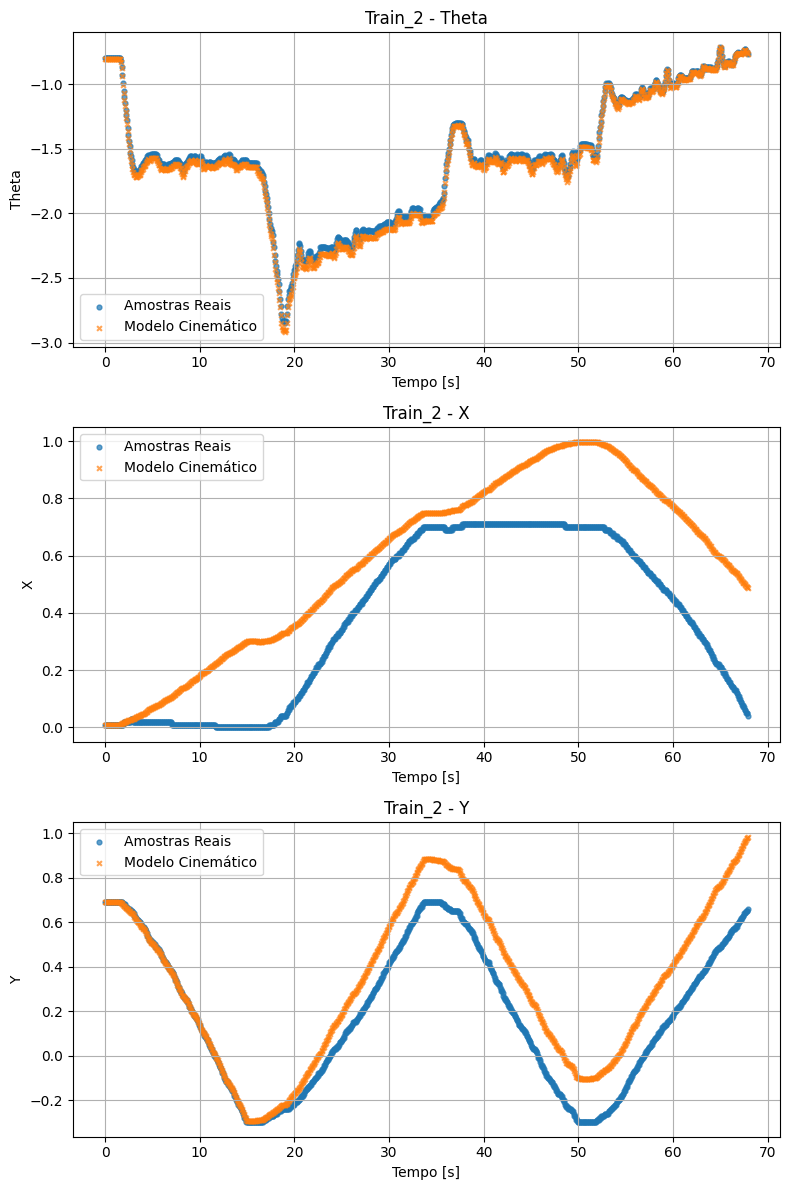

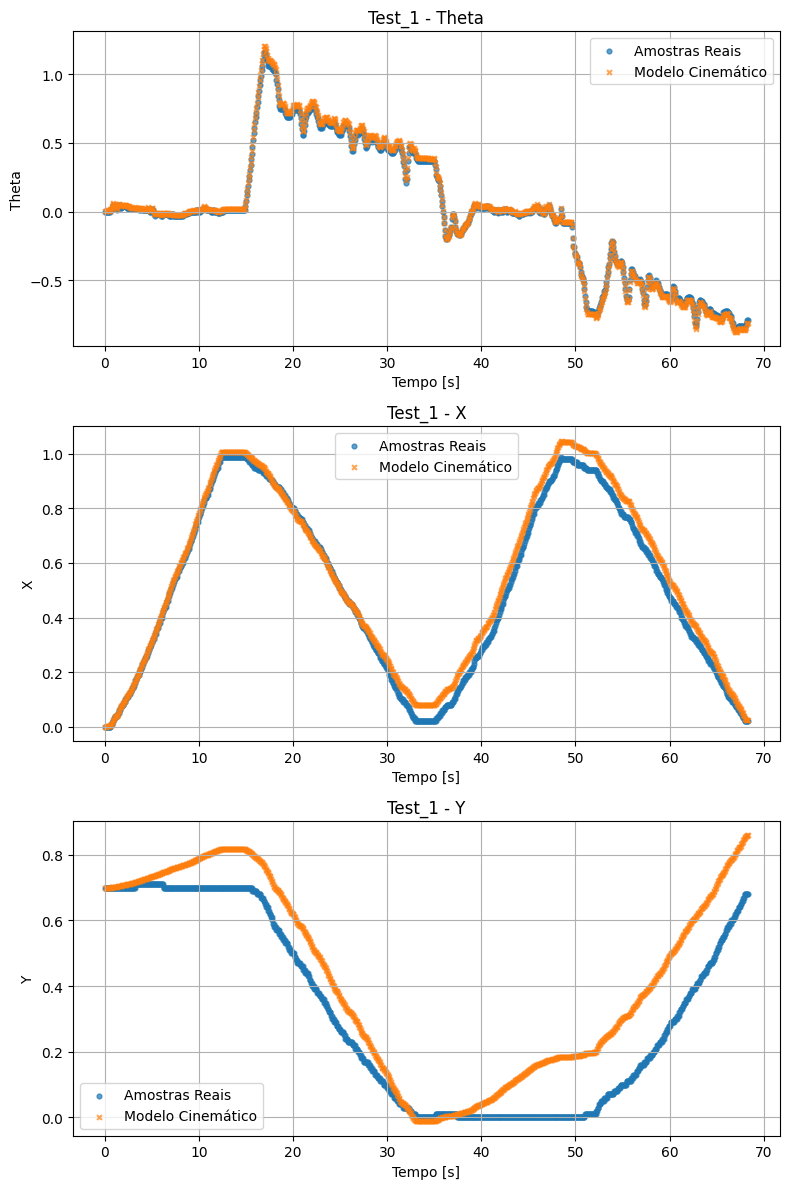

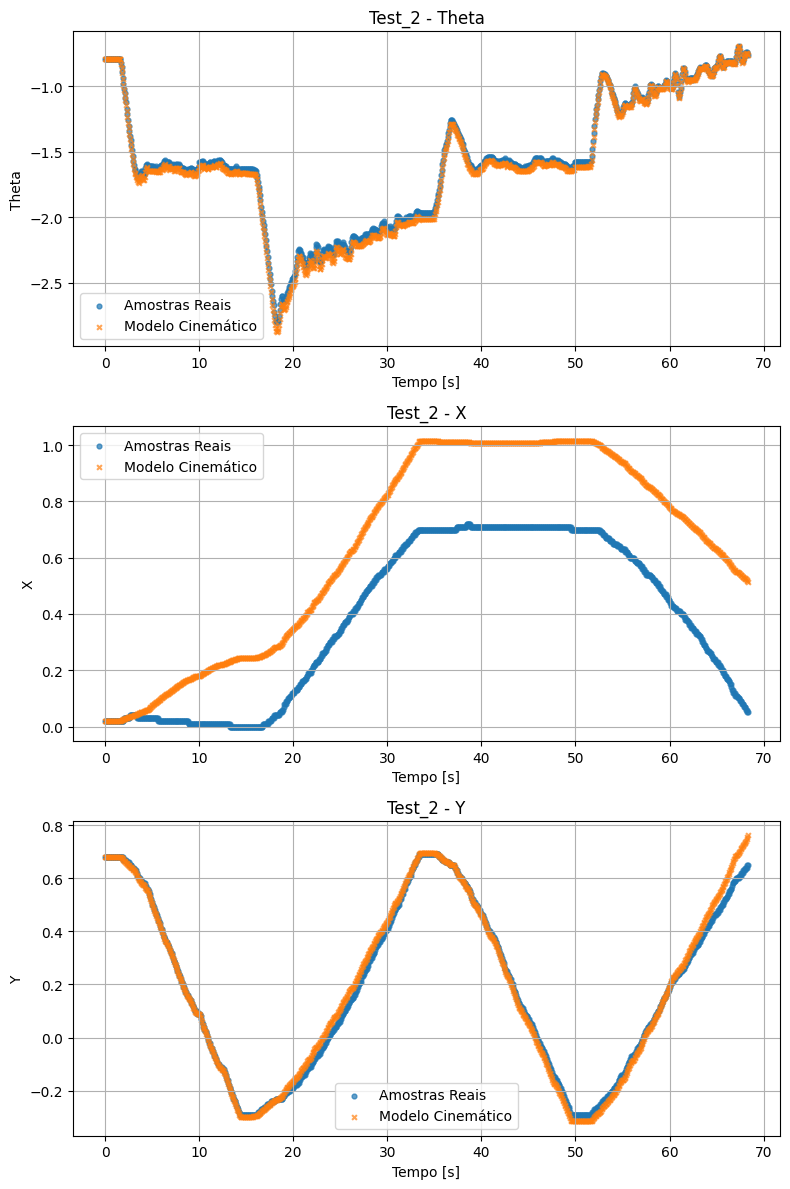

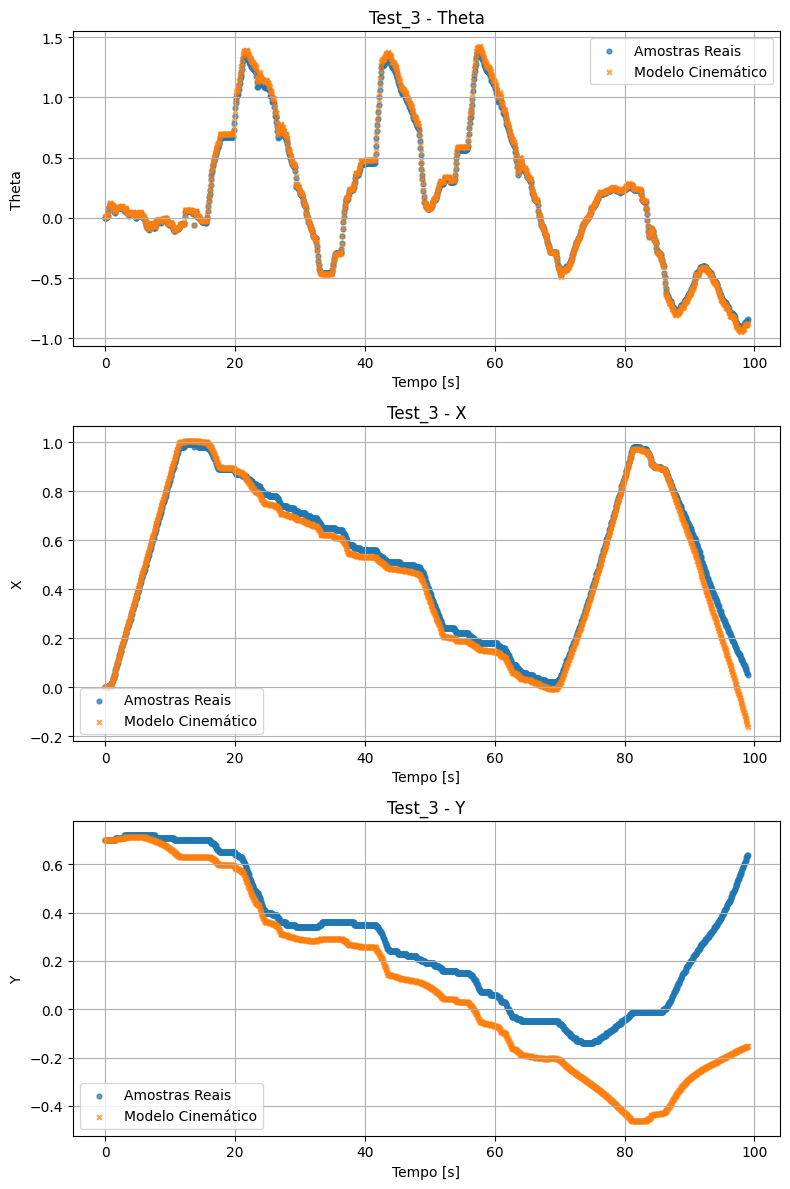

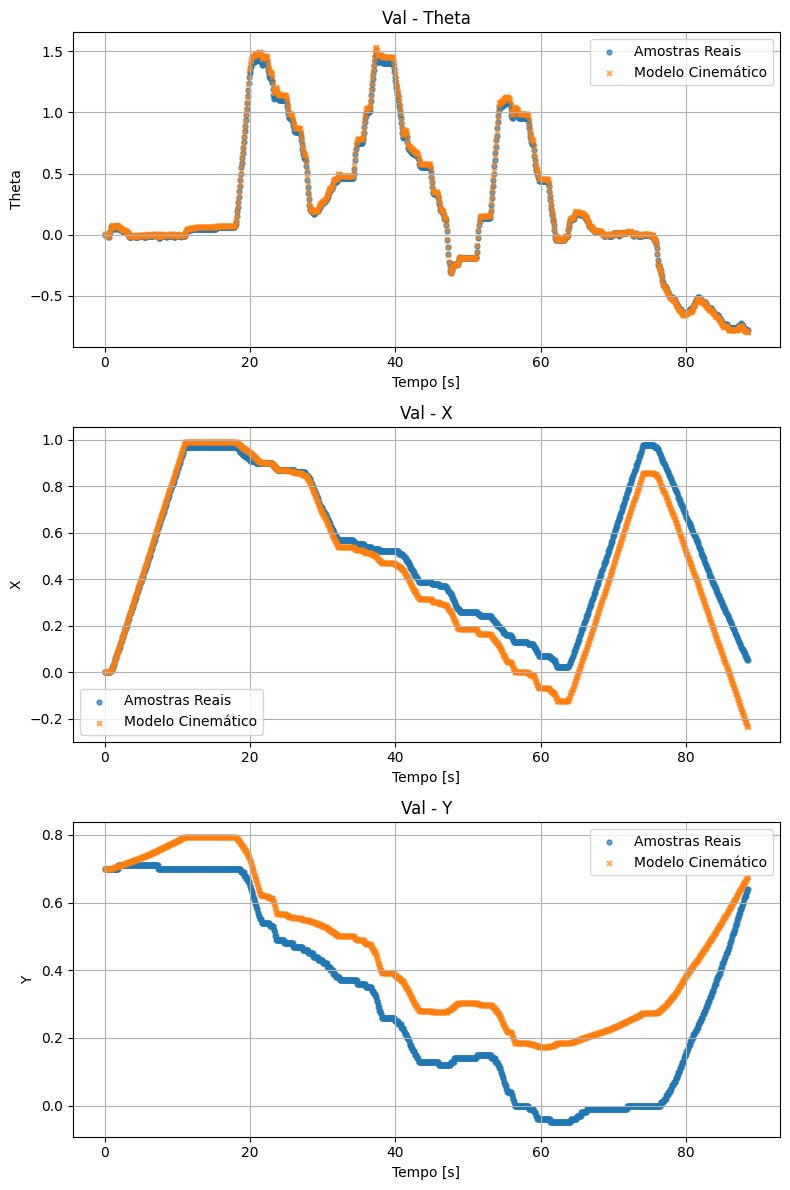

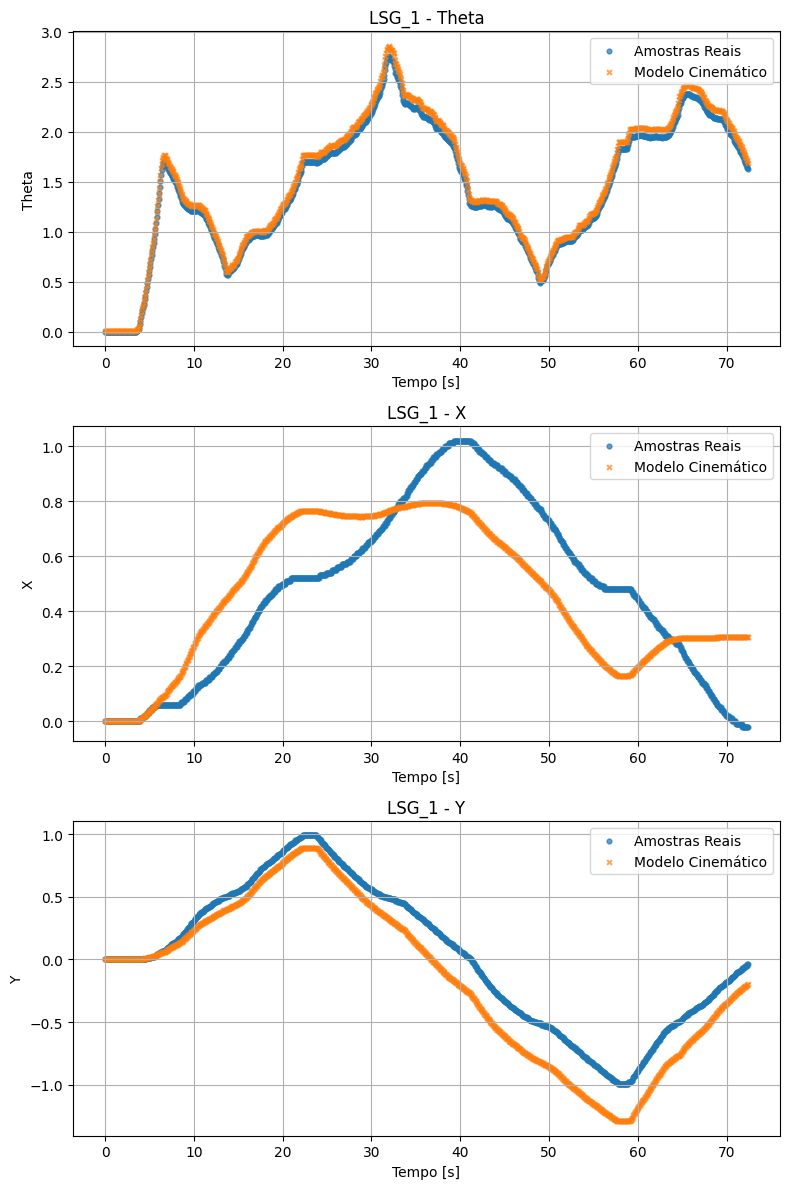

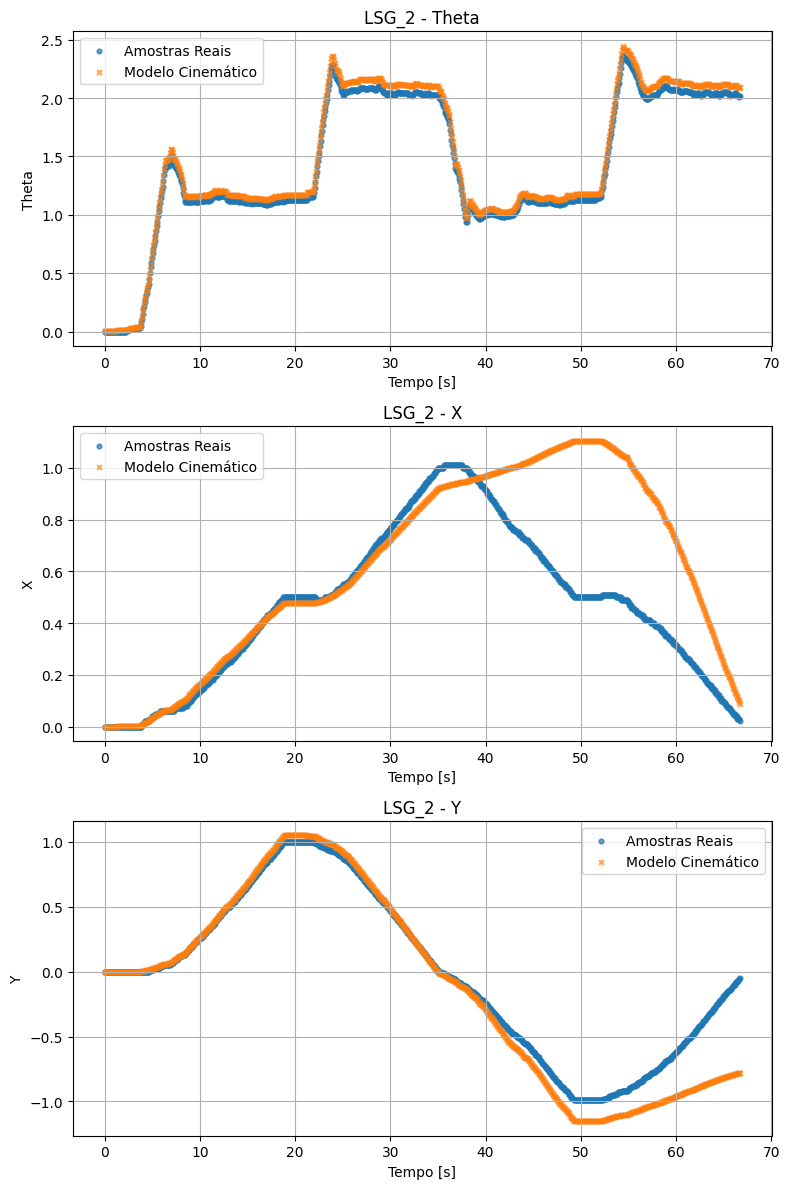

In [4]:
import matplotlib.pyplot as plt
import numpy as np

R = 0.0328
L = 0.0615
dt = 0.07


def CinematicModel(Wd, We, theta):
    dtheta_cin = (R / (2 * L)) * (Wd - We)
    dx_cin = (R / 2) * np.cos(theta) * (Wd + We)
    dy_cin = (R / 2) * np.sin(theta) * (Wd + We)

    return np.array([dtheta_cin, dx_cin, dy_cin])  # 🔹 melhor formato


def NumericalIntegration(dataset, dq):

    init_vals = np.array([
        dataset["Theta_ens"].iloc[0],
        dataset["X"].iloc[0],
        dataset["Y"].iloc[0]
    ])

    theta_cin = init_vals[0] + np.cumsum(dq[0] * dt)
    x_cin     = init_vals[1] + np.cumsum(dq[1] * dt)
    y_cin     = init_vals[2] + np.cumsum(dq[2] * dt)

    return np.array([theta_cin, x_cin, y_cin])


def PlotOut(ax, title, target_name, y_true, y_pred):
    time = (np.arange(len(y_pred)) * dt).round(5)

    ax.scatter(time, y_true, marker='o', s=12, label='Amostras Reais', alpha=0.7)
    ax.scatter(time, y_pred, marker='x', s=12, label='Modelo Cinemático', alpha=0.7)

    ax.set_title(f'{title} - {target_name}')
    ax.set_xlabel('Tempo [s]')
    ax.set_ylabel(target_name)
    ax.legend()
    ax.grid(True)


for title, dataset in zip(TITLES, Datasets):

    dq = CinematicModel(
        dataset["Wd"].values,
        dataset["We"].values,
        dataset["Theta_ens"].values
    )

    q = NumericalIntegration(dataset, dq)

    fig, ax = plt.subplots(3, 1, figsize=(8, 12))

    PlotOut(ax[0], title, "Theta", dataset["Theta"].values, q[0])
    PlotOut(ax[1], title, "X", dataset["X"].values, q[1])
    PlotOut(ax[2], title, "Y", dataset["Y"].values, q[2])

    plt.tight_layout()
    plt.show()